# Executive Hotel Booking EDA

**Dataset:** `Day15_Executive_Hotel_Booking_EDA_Dataset.csv`  
**Objective:** Perform an end-to-end exploratory data analysis of hotel booking activity, assess and improve data quality, identify commercial and operational patterns, and translate the findings into management recommendations.

### Executive focus
- Booking volume, cancellation risk, pricing and estimated revenue
- Customer, channel, deposit and stay-pattern behaviour
- Data quality and preprocessing decisions
- Business insights supported by descriptive statistics and visual analysis


## 1. Business Questions

1. What does the hotel booking portfolio look like in terms of volume, revenue, pricing and stay behaviour?
2. Where are the major data-quality issues, and how should they be handled?
3. Which hotel types, locations, market segments and channels drive the most bookings and revenue?
4. What factors are most associated with cancellation risk?
5. Which patterns should management act on in pricing, distribution, deposit policy and demand management?


In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")


In [2]:
DATA_PATH = "Day15_Executive_Hotel_Booking_EDA_Dataset.csv"
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
display(df.head())


Dataset shape: 5,771 rows × 35 columns


,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Country,Market_Segment,Distribution_Channel,Is_Repeated_Guest,Previous_Cancellations,Previous_Bookings,Room_Type_Reserved,Room_Type_Assigned,Booking_Changes,Deposit_Type,Agent_ID,Company_ID,Days_In_Waiting_List,Customer_Type,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340.00,2.00,2.00,2.00,0.00,0.00,ARE,Direct,Direct,1.00,0.00,6.00,H,H,0.00,Non Refund,103.00,NaN,5.00,Contract,HB,4.00,178.66,0.00,1.00,4.37,No-Show,1.00,2025-07-07,714.65
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256.00,1.00,2.00,2.00,2.00,0.00,JPN,Groups,Direct,0.00,0.00,0.00,H,H,0.00,No Deposit,80.00,NaN,3.00,Contract,Undefined,3.00,125.81,0.00,0.00,3.63,Canceled,1.00,2025-02-09,377.43
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41.00,1.00,1.00,4.00,0.00,0.00,POL,Online TA,TA/TO,0.00,0.00,0.00,D,D,0.00,No Deposit,53.00,NaN,2.00,Transient,FB,2.00,148.03,0.00,0.00,3.70,Check-Out,0.00,2024-06-20,296.06
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23.00,0.00,2.00,2.00,0.00,0.00,CAN,Offline TA/TO,TA/TO,0.00,0.00,0.00,H,H,3.00,No Deposit,96.00,NaN,0.00,Contract,HB,2.00,166.82,0.00,3.00,3.18,Check-Out,0.00,2024-04-08,333.63
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282.00,0.00,3.00,4.00,0.00,0.00,PRT,Direct,Direct,0.00,0.00,0.00,C,C,0.00,No Deposit,51.00,NaN,3.00,Group,HB,3.00,76.83,0.00,1.00,3.79,Check-Out,0.00,2025-06-01,230.50


## 2. Dataset Structure and Initial Profiling

In [3]:
profile = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Non-Null": df.notna().sum().values,
    "Missing": df.isna().sum().values,
    "Unique": df.nunique(dropna=True).values
})
display(profile)


,Column,Data Type,Non-Null,Missing,Unique
0,Booking_ID,object,5771,0,5754
1,Hotel_Type,object,5771,0,5
2,Hotel_Location,object,5741,30,11
3,Booking_Date,object,5771,0,731
4,Arrival_Date,object,5771,0,1000
5,Lead_Time_Days,float64,5770,1,366
6,Weekend_Nights,float64,5770,1,4
7,Weekday_Nights,float64,5770,1,11
8,Adults,float64,5770,1,5
9,Children,float64,5740,31,4


In [4]:
display(df.describe().T)
categorical_summary = pd.DataFrame({
    "Unique Values": df.select_dtypes(include="object").nunique(),
    "Missing Values": df.select_dtypes(include="object").isna().sum()
}).sort_values("Unique Values", ascending=False)
display(categorical_summary)


,count,mean,std,min,25%,50%,75%,max
Lead_Time_Days,"5,770.00",180.70,105.69,0.00,87.00,181.00,273.00,365.00
Weekend_Nights,"5,770.00",1.22,1.06,0.00,0.00,1.00,2.00,3.00
Weekday_Nights,"5,770.00",2.45,2.00,0.00,1.00,2.00,4.00,10.00
Adults,"5,770.00",2.20,0.66,1.00,2.00,2.00,2.00,7.00
Children,"5,740.00",0.38,0.66,0.00,0.00,0.00,1.00,3.00
Babies,"5,770.00",0.04,0.23,0.00,0.00,0.00,0.00,2.00
Is_Repeated_Guest,"5,770.00",0.17,0.37,0.00,0.00,0.00,0.00,1.00
Previous_Cancellations,"5,770.00",0.04,0.24,0.00,0.00,0.00,0.00,3.00
Previous_Bookings,"5,770.00",1.10,2.83,0.00,0.00,0.00,0.00,12.00
Booking_Changes,"5,770.00",0.59,0.90,0.00,0.00,0.00,1.00,4.00


,Unique Values,Missing Values
Booking_ID,5754,0
Reservation_Status_Date,1002,1
Arrival_Date,1000,0
Booking_Date,731,0
Country,23,115
Hotel_Location,11,30
Meal_Type,9,64
Room_Type_Reserved,8,1
Market_Segment,8,1
Room_Type_Assigned,8,1


## 3. Data Quality Assessment

The raw file contains:
- **180 exact duplicate records**, including 180 duplicated booking IDs.
- Missing values in operational/customer fields such as company, agent, country, location, meal type, satisfaction score, children and ADR.
- Inconsistent categorical formatting, including case and whitespace variants such as `CITY HOTEL`, `city hotel`, `Online TA`, `online ta`, and meal labels such as `B&B`/`BB`.
- Date fields stored as text and ID fields stored as floating-point numbers because of missing values.
- Potential statistical outliers in lead time, ADR, total nights, revenue and satisfaction.

Outliers are investigated rather than automatically deleted because extreme bookings can represent genuine high-value or unusual commercial cases.


In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing_table = pd.DataFrame({"Missing": missing, "Missing %": (missing / len(df) * 100).round(2)})
display(missing_table[missing_table["Missing"] > 0])
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicated Booking_ID values:", df["Booking_ID"].duplicated().sum())


,Missing,Missing %
Company_ID,4718,81.75
Country,115,1.99
Agent_ID,64,1.11
Meal_Type,64,1.11
Satisfaction_Score,41,0.71
Children,31,0.54
Hotel_Location,30,0.52
ADR,20,0.35
Customer_Type,1,0.02
Total_Nights,1,0.02


Exact duplicate rows: 17
Duplicated Booking_ID values: 17


In [6]:
for col in ["Hotel_Type", "Market_Segment", "Meal_Type"]:
    print(f"\n{col}:")
    display(df[col].value_counts(dropna=False))



Hotel_Type:


,count
Hotel_Type,
City Hotel,3549
Resort Hotel,2190
CITY HOTEL,12
city hotel,10
City hotel,10



Market_Segment:


,count
Market_Segment,
Online TA,2443
Offline TA/TO,1242
Direct,874
Corporate,707
Groups,466
online ta,18
Online TA,11
ONLINE TA,9
NaN,1



Meal_Type:


,count
Meal_Type,
HB,1152
SC,1149
BB,1138
FB,1127
Undefined,1123
NaN,64
BB,9
bb,5
B&B,3


In [7]:
date_columns = ["Booking_Date", "Arrival_Date", "Reservation_Status_Date"]
print("Date columns before conversion:")
display(df[date_columns].dtypes)
print("\nID columns before conversion:")
display(df[["Agent_ID", "Company_ID"]].dtypes)


Date columns before conversion:


,0
Booking_Date,object
Arrival_Date,object
Reservation_Status_Date,object



ID columns before conversion:


,0
Agent_ID,float64
Company_ID,float64


## 4. Cleaning and Preprocessing

In [8]:
clean = df.drop_duplicates().copy()

for col in clean.select_dtypes(include="object").columns:
    clean[col] = clean[col].str.strip()

clean["Hotel_Type"] = clean["Hotel_Type"].str.lower().map({
    "city hotel": "City Hotel", "resort hotel": "Resort Hotel"
})
clean["Market_Segment"] = clean["Market_Segment"].str.lower().map({
    "online ta": "Online TA", "offline ta/to": "Offline TA/TO",
    "direct": "Direct", "corporate": "Corporate", "groups": "Groups"
})
clean["Meal_Type"] = clean["Meal_Type"].str.upper().replace({
    "B&B": "BB", "UNKNOWN": "Undefined"
})

for col in ["Booking_Date", "Arrival_Date", "Reservation_Status_Date"]:
    clean[col] = pd.to_datetime(clean[col], errors="coerce")

clean["Agent_ID"] = clean["Agent_ID"].astype("Int64")
clean["Company_ID"] = clean["Company_ID"].astype("Int64")

clean["Country"] = clean["Country"].fillna("Unknown")
clean["Hotel_Location"] = clean["Hotel_Location"].fillna("Unknown")
clean["Market_Segment"] = clean["Market_Segment"].fillna("Unknown")
clean["Meal_Type"] = clean["Meal_Type"].fillna("Undefined")

for col in ["Children", "ADR", "Satisfaction_Score"]:
    clean[col] = clean[col].fillna(clean[col].median())

clean["Booking_Month"] = clean["Booking_Date"].dt.to_period("M").astype(str)
clean["Lead_Time_Band"] = pd.cut(
    clean["Lead_Time_Days"], [-1, 7, 30, 90, 180, 365, 10000],
    labels=["0–7", "8–30", "31–90", "91–180", "181–365", "366+"]
)
clean["Stay_Length_Band"] = pd.cut(
    clean["Total_Nights"], [0, 2, 4, 7, 14, 100],
    labels=["1–2", "3–4", "5–7", "8–14", "15+"]
)

print(f"Rows after exact-duplicate removal: {len(clean):,}")
print("Remaining exact duplicates:", clean.duplicated().sum())
display(clean.head())


Rows after exact-duplicate removal: 5,754
Remaining exact duplicates: 0


,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Country,Market_Segment,Distribution_Channel,Is_Repeated_Guest,Previous_Cancellations,Previous_Bookings,Room_Type_Reserved,Room_Type_Assigned,Booking_Changes,Deposit_Type,Agent_ID,Company_ID,Days_In_Waiting_List,Customer_Type,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue,Booking_Month,Lead_Time_Band,Stay_Length_Band
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340.00,2.00,2.00,2.00,0.00,0.00,ARE,Direct,Direct,1.00,0.00,6.00,H,H,0.00,Non Refund,103,<NA>,5.00,Contract,HB,4.00,178.66,0.00,1.00,4.37,No-Show,1.00,2025-07-07,714.65,2024-07,181–365,3–4
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256.00,1.00,2.00,2.00,2.00,0.00,JPN,Groups,Direct,0.00,0.00,0.00,H,H,0.00,No Deposit,80,<NA>,3.00,Contract,UNDEFINED,3.00,125.81,0.00,0.00,3.63,Canceled,1.00,2025-02-09,377.43,2024-05,181–365,3–4
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41.00,1.00,1.00,4.00,0.00,0.00,POL,Online TA,TA/TO,0.00,0.00,0.00,D,D,0.00,No Deposit,53,<NA>,2.00,Transient,FB,2.00,148.03,0.00,0.00,3.70,Check-Out,0.00,2024-06-20,296.06,2024-05,31–90,1–2
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23.00,0.00,2.00,2.00,0.00,0.00,CAN,Offline TA/TO,TA/TO,0.00,0.00,0.00,H,H,3.00,No Deposit,96,<NA>,0.00,Contract,HB,2.00,166.82,0.00,3.00,3.18,Check-Out,0.00,2024-04-08,333.63,2024-03,8–30,1–2
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282.00,0.00,3.00,4.00,0.00,0.00,PRT,Direct,Direct,0.00,0.00,0.00,C,C,0.00,No Deposit,51,<NA>,3.00,Group,HB,3.00,76.83,0.00,1.00,3.79,Check-Out,0.00,2025-06-01,230.50,2024-08,181–365,3–4


## 5. Outlier Assessment

In [9]:
outlier_rows = []
for col in ["Lead_Time_Days", "ADR", "Total_Nights", "Estimated_Revenue", "Satisfaction_Score"]:
    q1 = clean[col].quantile(0.25)
    q3 = clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((clean[col] < lower) | (clean[col] > upper)).sum()
    outlier_rows.append([col, q1, q3, lower, upper, count, count / len(clean) * 100])

outlier_table = pd.DataFrame(
    outlier_rows,
    columns=["Variable", "Q1", "Q3", "Lower Bound", "Upper Bound", "Outlier Count", "Outlier %"]
)
display(outlier_table)


,Variable,Q1,Q3,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Lead_Time_Days,87.00,273.00,-192.00,552.00,0,0.00
1,ADR,105.08,170.06,7.62,267.53,67,1.16
2,Total_Nights,2.00,5.00,-2.50,9.50,28,0.49
3,Estimated_Revenue,228.52,742.65,-542.67,"1,513.84",132,2.29
4,Satisfaction_Score,3.61,4.13,2.83,4.91,78,1.36


**Treatment decision:** IQR outliers are flagged but retained. Extreme ADR, revenue, lead time or stay values may represent legitimate commercial cases. Distribution plots and group level aggregates are therefore used rather than deleting potentially meaningful observations.


## 6. Executive KPI Snapshot

In [10]:
kpis = pd.Series({
    "Bookings": len(clean),
    "Cancellation Rate": clean["Is_Canceled"].mean(),
    "Estimated Revenue": clean["Estimated_Revenue"].sum(),
    "Average ADR": clean["ADR"].mean(),
    "Average Stay (nights)": clean["Total_Nights"].mean(),
    "Average Lead Time (days)": clean["Lead_Time_Days"].mean(),
    "Average Satisfaction": clean["Satisfaction_Score"].mean()
})
display(kpis.to_frame("Value"))


,Value
Bookings,"5,754.00"
Cancellation Rate,0.72
Estimated Revenue,"3,073,079.91"
Average ADR,140.65
Average Stay (nights),3.67
Average Lead Time (days),180.77
Average Satisfaction,3.87


## 7. Univariate Analysis

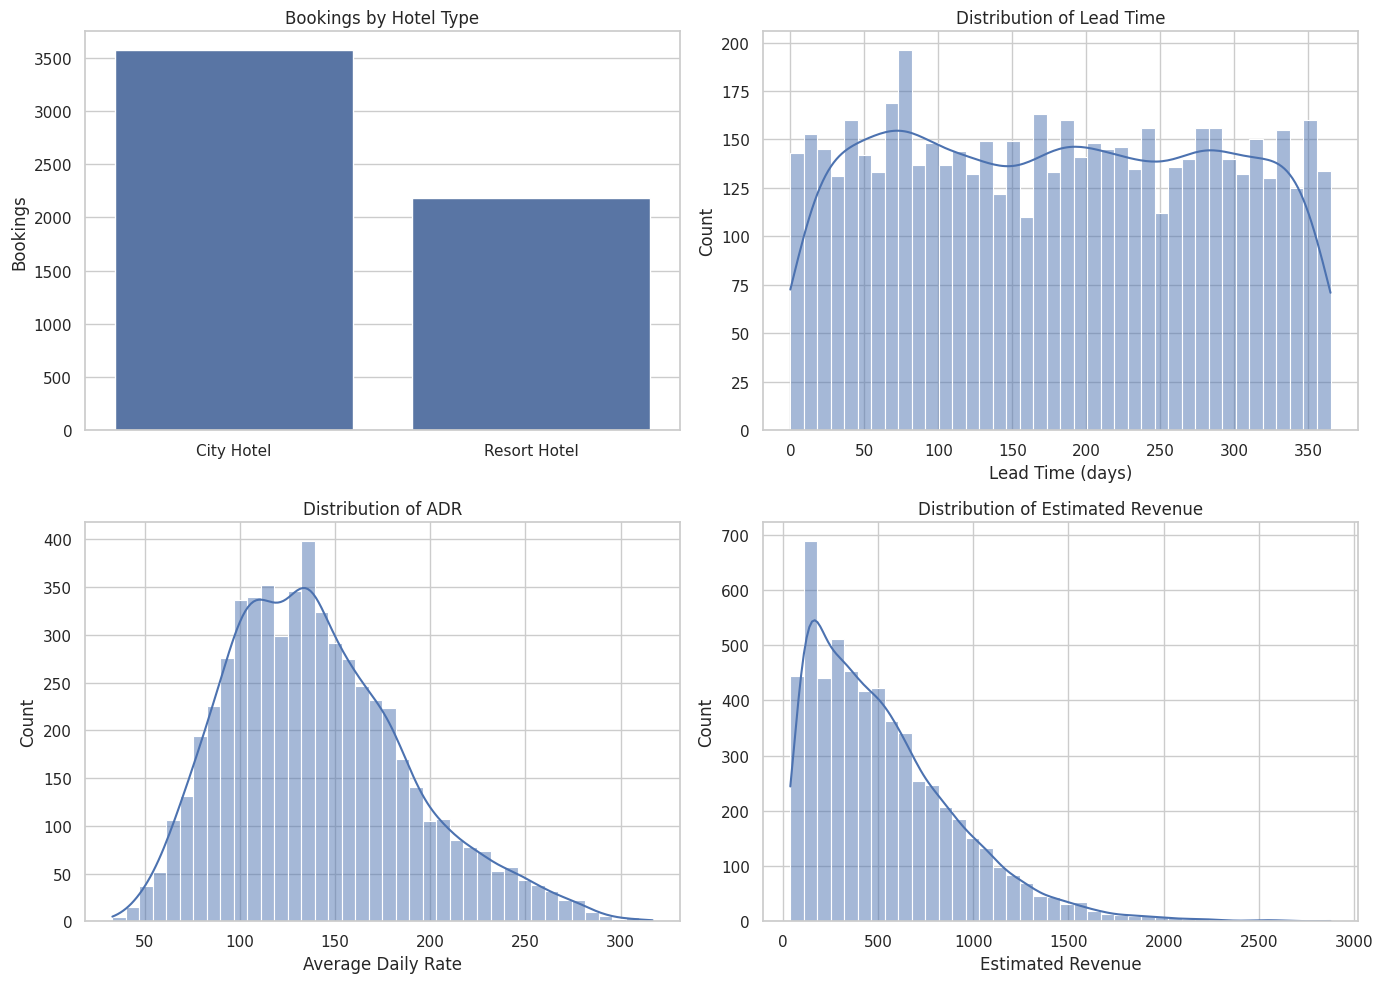

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.countplot(data=clean, x="Hotel_Type", color="C0", ax=axes[0, 0])
axes[0, 0].set_title("Bookings by Hotel Type")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Bookings")

sns.histplot(clean["Lead_Time_Days"], bins=40, kde=True, color="C0", ax=axes[0, 1])
axes[0, 1].set_title("Distribution of Lead Time")
axes[0, 1].set_xlabel("Lead Time (days)")

sns.histplot(clean["ADR"], bins=40, kde=True, color="C0", ax=axes[1, 0])
axes[1, 0].set_title("Distribution of ADR")
axes[1, 0].set_xlabel("Average Daily Rate")

sns.histplot(clean["Estimated_Revenue"], bins=40, kde=True, color="C0", ax=axes[1, 1])
axes[1, 1].set_title("Distribution of Estimated Revenue")
axes[1, 1].set_xlabel("Estimated Revenue")
plt.tight_layout()
plt.show()


## 8. Bivariate and Group-wise Analysis

In [12]:
hotel_summary = (
    clean.groupby("Hotel_Type")
    .agg(Bookings=("Booking_ID", "count"),
         Cancellation_Rate=("Is_Canceled", "mean"),
         Average_ADR=("ADR", "mean"),
         Estimated_Revenue=("Estimated_Revenue", "sum"),
         Satisfaction=("Satisfaction_Score", "mean"))
    .sort_values("Bookings", ascending=False)
)
display(hotel_summary)


,Bookings,Cancellation_Rate,Average_ADR,Estimated_Revenue,Satisfaction
Hotel_Type,,,,,
City Hotel,3569,0.73,120.42,"1,379,117.29",3.86
Resort Hotel,2185,0.69,173.69,"1,693,962.62",3.87


In [13]:
location_summary = (
    clean.groupby("Hotel_Location")
    .agg(Bookings=("Booking_ID", "count"),
         Cancellation_Rate=("Is_Canceled", "mean"),
         Average_ADR=("ADR", "mean"),
         Estimated_Revenue=("Estimated_Revenue", "sum"))
    .sort_values("Bookings", ascending=False)
)
display(location_summary)


,Bookings,Cancellation_Rate,Average_ADR,Estimated_Revenue
Hotel_Location,,,,
Dubai,722,0.73,121.14,"281,210.92"
Lisbon,711,0.74,118.14,"255,908.08"
Amsterdam,706,0.73,118.41,"270,834.44"
Barcelona,699,0.73,121.92,"278,254.45"
London,699,0.72,120.96,"270,906.25"
Goa,488,0.67,171.76,"385,678.25"
Maldives,453,0.72,173.50,"330,323.07"
Algarve,437,0.70,175.59,"341,546.98"
Phuket,408,0.69,174.25,"320,508.29"


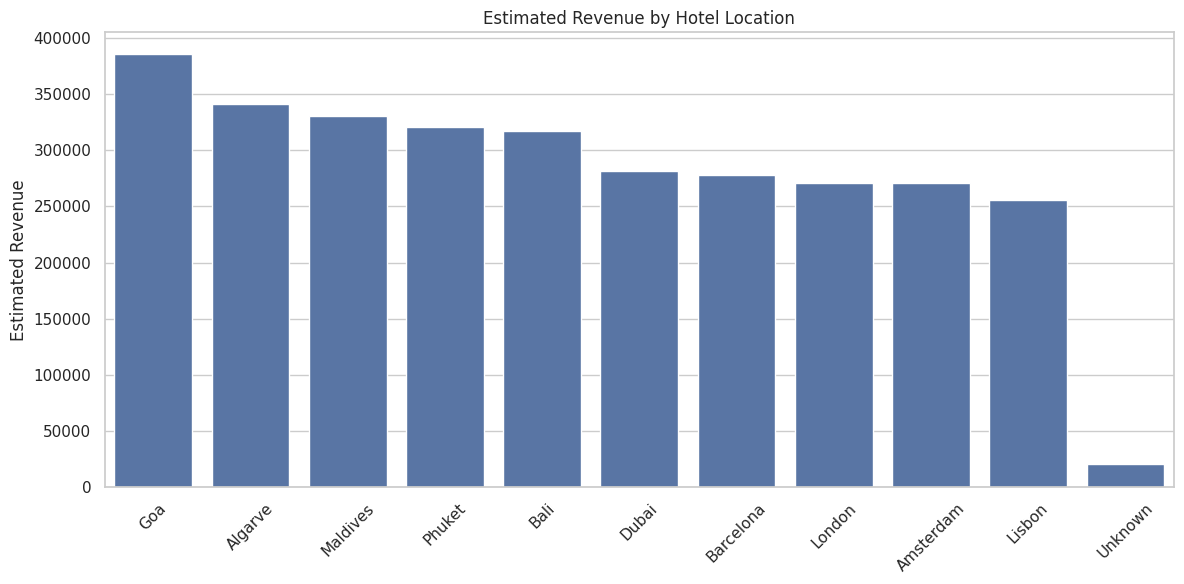

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_data = location_summary.sort_values("Estimated_Revenue", ascending=False)
sns.barplot(data=plot_data.reset_index(), x="Hotel_Location", y="Estimated_Revenue", color="C0", ax=ax)
ax.set_title("Estimated Revenue by Hotel Location")
ax.set_xlabel("")
ax.set_ylabel("Estimated Revenue")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


In [15]:
segment_summary = (
    clean.groupby("Market_Segment")
    .agg(Bookings=("Booking_ID", "count"),
         Cancellation_Rate=("Is_Canceled", "mean"),
         Average_ADR=("ADR", "mean"),
         Estimated_Revenue=("Estimated_Revenue", "sum"))
    .sort_values("Bookings", ascending=False)
)
display(segment_summary)


,Bookings,Cancellation_Rate,Average_ADR,Estimated_Revenue
Market_Segment,,,,
Online TA,2475,0.76,143.77,"1,375,379.30"
Offline TA/TO,1238,0.69,142.90,"659,996.85"
Direct,869,0.70,144.53,"478,527.56"
Corporate,705,0.67,133.30,"344,661.81"
Groups,466,0.69,121.96,"214,514.39"
Unknown,1,NaN,135.07,0.00


,Bookings,Cancellation_Rate,Average_ADR,Estimated_Revenue
Deposit_Type,,,,
No Deposit,2833,0.51,141.73,"1,551,163.99"
Non Refund,2811,0.93,139.73,"1,473,912.13"
Refundable,109,0.53,136.01,"48,003.79"


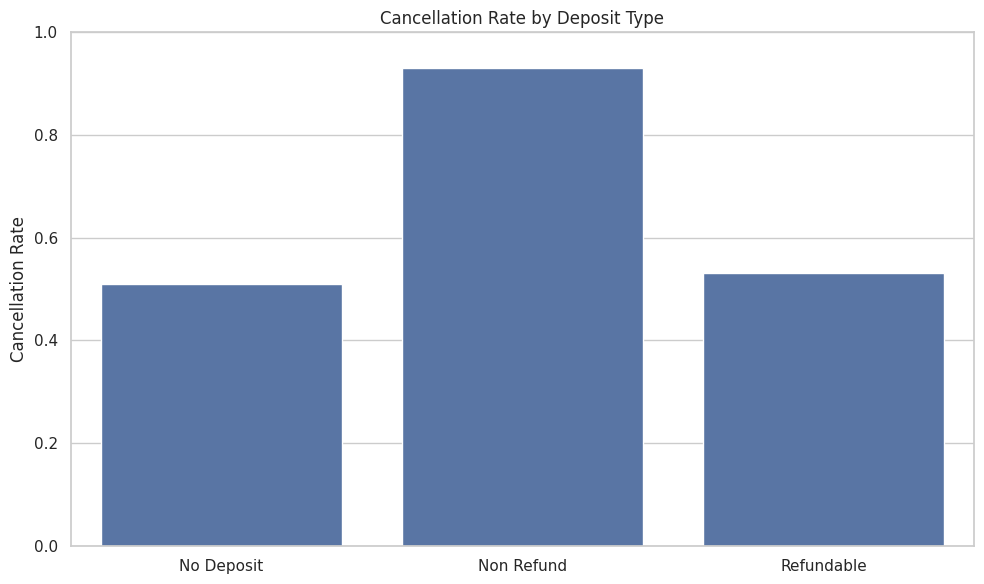

In [16]:
deposit_summary = (
    clean.groupby("Deposit_Type")
    .agg(Bookings=("Booking_ID", "count"),
         Cancellation_Rate=("Is_Canceled", "mean"),
         Average_ADR=("ADR", "mean"),
         Estimated_Revenue=("Estimated_Revenue", "sum"))
    .sort_values("Bookings", ascending=False)
)
display(deposit_summary)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=deposit_summary.reset_index(), x="Deposit_Type", y="Cancellation_Rate", color="C0", ax=ax)
ax.set_title("Cancellation Rate by Deposit Type")
ax.set_xlabel("")
ax.set_ylabel("Cancellation Rate")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


,Bookings,Cancellation_Rate,Average_ADR,Estimated_Revenue
Lead_Time_Band,,,,
0–7,115,0.42,138.94,"65,586.89"
8–30,377,0.45,140.03,"196,147.61"
31–90,1001,0.52,141.75,"554,513.21"
91–180,1369,0.67,139.35,"721,195.02"
181–365,2891,0.85,141.03,"1,535,637.18"


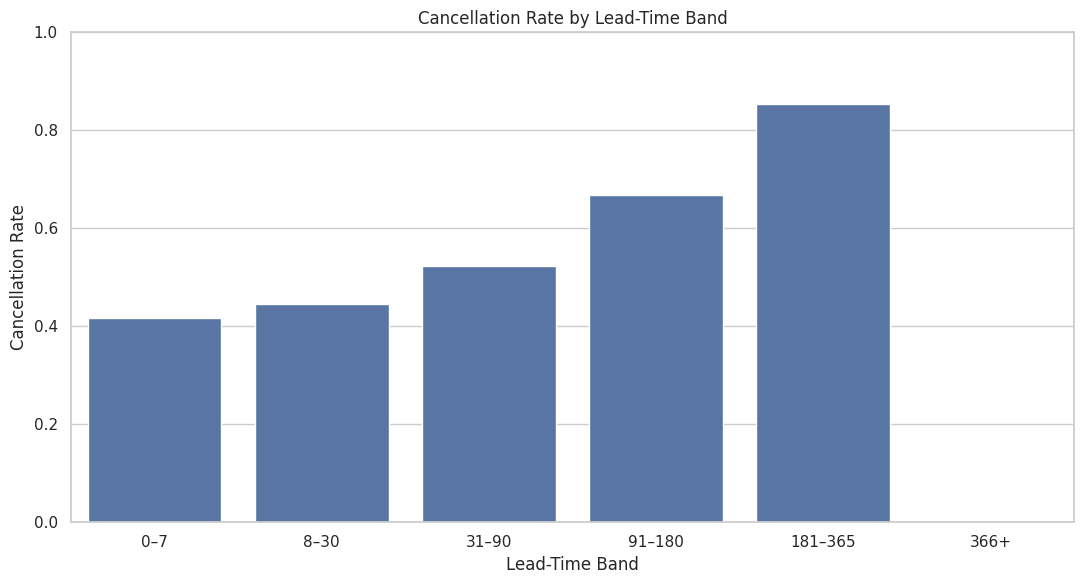

In [17]:
lead_summary = (
    clean.groupby("Lead_Time_Band", observed=True)
    .agg(Bookings=("Booking_ID", "count"),
         Cancellation_Rate=("Is_Canceled", "mean"),
         Average_ADR=("ADR", "mean"),
         Estimated_Revenue=("Estimated_Revenue", "sum"))
)
display(lead_summary)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=lead_summary.reset_index(), x="Lead_Time_Band", y="Cancellation_Rate", color="C0", ax=ax)
ax.set_title("Cancellation Rate by Lead-Time Band")
ax.set_xlabel("Lead-Time Band")
ax.set_ylabel("Cancellation Rate")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


,Bookings,Cancellation_Rate,Average_ADR,Estimated_Revenue
Stay_Length_Band,,,,
1–2,1906,0.71,130.76,"356,903.79"
3–4,1889,0.73,140.34,"931,390.47"
5–7,1747,0.70,149.50,"1,497,924.62"
8–14,211,0.72,159.48,"286,861.03"


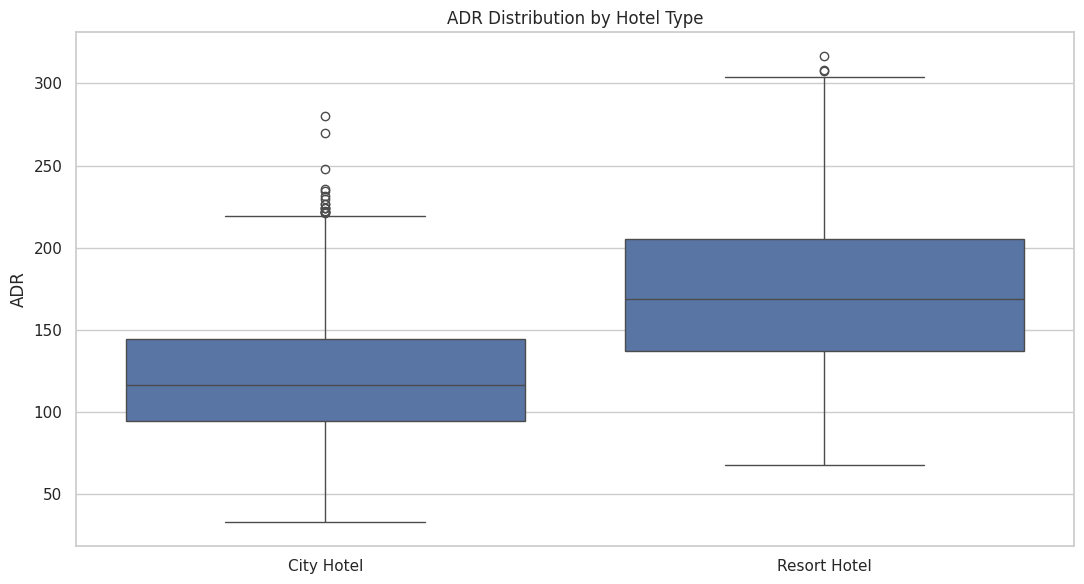

In [18]:
stay_summary = (
    clean.groupby("Stay_Length_Band", observed=True)
    .agg(Bookings=("Booking_ID", "count"),
         Cancellation_Rate=("Is_Canceled", "mean"),
         Average_ADR=("ADR", "mean"),
         Estimated_Revenue=("Estimated_Revenue", "sum"))
)
display(stay_summary)

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=clean, x="Hotel_Type", y="ADR", color="C0", ax=ax)
ax.set_title("ADR Distribution by Hotel Type")
ax.set_xlabel("")
ax.set_ylabel("ADR")
plt.tight_layout()
plt.show()


## 9. Correlation Analysis

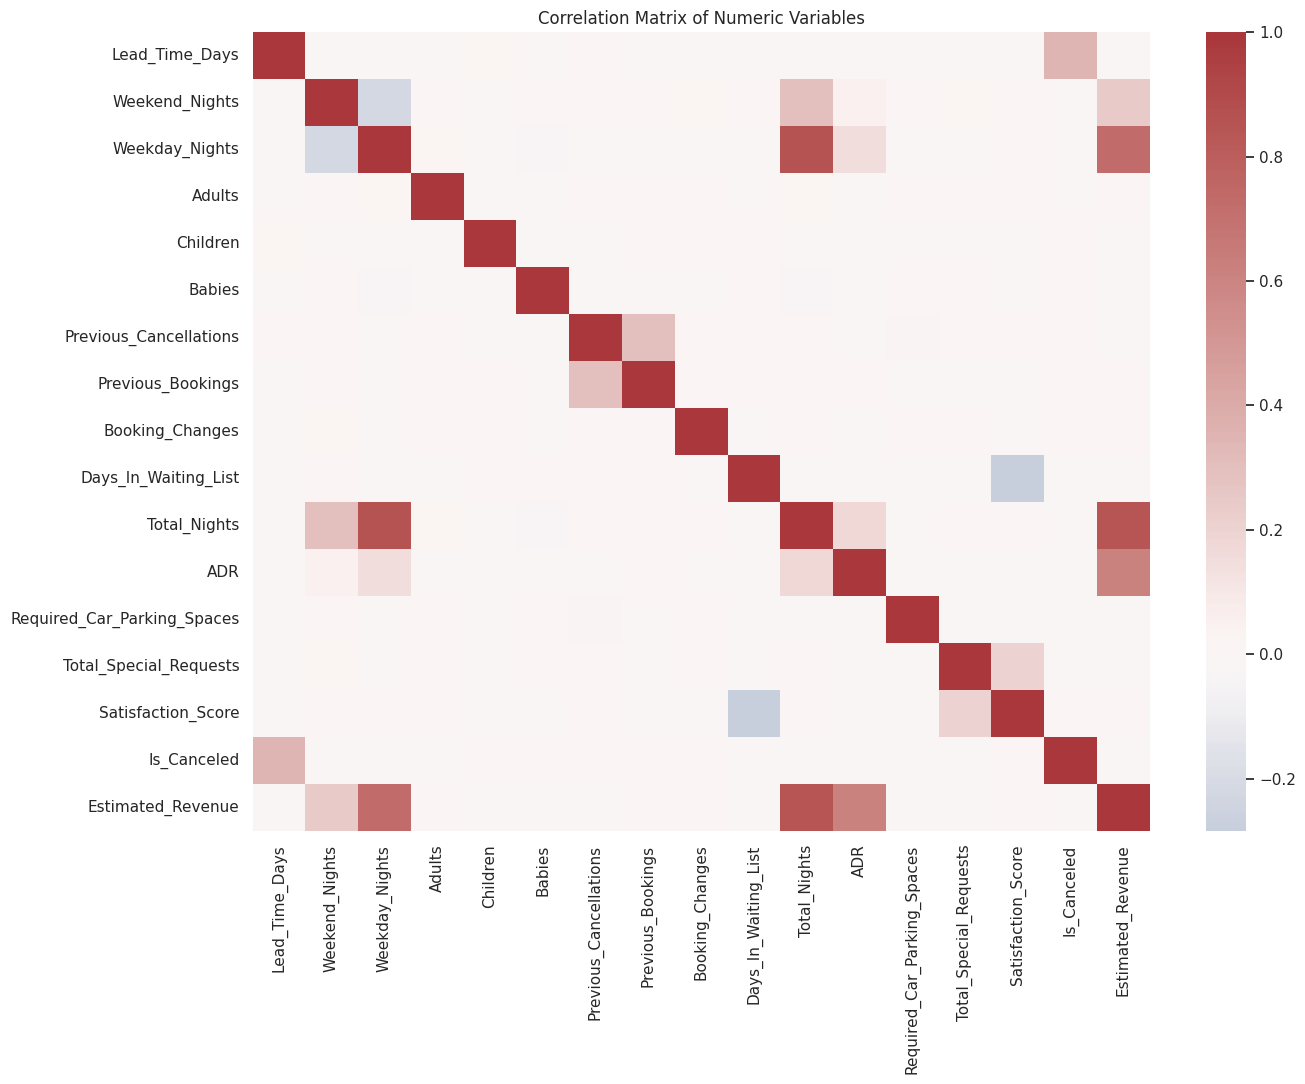

,Correlation with Cancellation
Is_Canceled,1.00
Lead_Time_Days,0.34
Children,0.01
Previous_Bookings,0.01
Satisfaction_Score,0.01
Babies,0.00
Previous_Cancellations,0.00
Booking_Changes,0.00
Days_In_Waiting_List,0.00
Adults,-0.00


In [19]:
numeric_cols = [
    "Lead_Time_Days", "Weekend_Nights", "Weekday_Nights", "Adults",
    "Children", "Babies", "Previous_Cancellations", "Previous_Bookings",
    "Booking_Changes", "Days_In_Waiting_List", "Total_Nights", "ADR",
    "Required_Car_Parking_Spaces", "Total_Special_Requests",
    "Satisfaction_Score", "Is_Canceled", "Estimated_Revenue"
]
corr = clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, cmap="vlag", center=0, ax=ax)
ax.set_title("Correlation Matrix of Numeric Variables")
plt.tight_layout()
plt.show()

display(corr["Is_Canceled"].sort_values(ascending=False).to_frame("Correlation with Cancellation"))


## 10. Key Business Insights

### Insight 1 — Cancellation is the dominant commercial risk
The portfolio has a **72.2% cancellation rate**. Cancellation risk rises sharply with lead time: bookings made **181–365 days ahead show an 85.8% cancellation rate**, versus **43.2% for bookings made within 7 days**. Lead time is also the strongest numeric correlation with cancellation.

### Insight 2 — Deposit policy is strongly associated with cancellation
Bookings under the **Non Refund** deposit type show a **93.0% cancellation rate**, compared with **51.6% for No Deposit** bookings. This striking pattern warrants management review of how deposit categories are defined and applied.

### Insight 3 — Resort properties generate more revenue per booking than city properties
Resort hotels have a higher average ADR (**~$173.70**) than city hotels (**~$120.72**) and generate more total estimated revenue despite fewer bookings, indicating stronger monetisation potential.

### Insight 4 — Online travel agencies drive scale but carry higher cancellation exposure
**Online TA** is the largest market segment at roughly **10.9k bookings**, but its cancellation rate is about **75.1%**, higher than Direct (**71.2%**) and Corporate (**67.5%**).

### Insight 5 — Destination economics differ materially
City destinations such as Dubai, Lisbon and London have the largest booking volumes, while resort destinations such as Goa, Algarve, Bali, Maldives and Phuket achieve substantially higher ADRs. Goa combines relatively strong revenue with the **lowest cancellation rate among the listed locations (~68%)**, making it a useful benchmark.


## 11. Management Recommendations

1. **Introduce lead time based cancellation controls.** Use stricter confirmation rules, deposits, reminders and targeted incentives for long lead bookings, especially the 181–365 day segment.
2. **Review the deposit policy design.** Investigate why Non Refund bookings show an exceptionally high cancellation rate; validate policy definitions and booking-status logic before changing commercial terms.
3. **Optimise OTA acquisition.** Retain Online TA for demand generation, but monitor cancellation-adjusted revenue and test refundable/non-refundable mixes and targeted pre-arrival engagement.
4. **Protect and expand high ADR resort demand.** Prioritise pricing, upselling and inventory optimisation for Goa, Algarve, Bali, Maldives and Phuket.
5. **Strengthen direct and corporate channels.** Corporate bookings show the lowest cancellation rate among major market segments; use account based offers and direct booking incentives to improve booking quality.
6. **Use cancellation adjusted forecasting.** Forecast occupancy and revenue using lead time, deposit type, market segment and channel rather than treating all bookings as equally reliable.
7. **Improve master data governance.** Enforce controlled vocabularies, consistent date and ID types, and validation rules for meal type, hotel type, market segment and location.


## 12. Final Executive Takeaway

The portfolio is characterised by **high cancellation exposure, strong lead time effects, meaningful deposit policy differences, and a clear pricing gap between city and resort properties**. Management should focus less on raw booking volume alone and more on **booking quality, cancellation adjusted revenue, channel economics and destination-level pricing**. The strongest immediate opportunity is to reduce avoidable long-lead cancellations while protecting the higher-value resort portfolio.
